# Кластеризация ЕГЭ (8.5 если сделаны все задачи)

Рядом лежат экселевские таблицы с координатами точек. В 3 и 4 задаче используется манхетеское расстояние. В остальных Евклидово.

* Постройте Распределение точек
* Кластеризуйте руками
* Постройте Распределение точек, отметьте принадлежность кластеров цветами
* Найдите среди в каждом кластере точку расстояние от которой до всех остальных минимально
* Выведите усреднение центров всех кластеров * 1000

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Кластеризация (0.75 за каждый алгоритм на всех данных)

На предложенных распределениях данных проверьте предложенные алгоритмы. Постройте графики кластеризации для каждой пары алгоритм-данные, разные кластеры покрасьте разным цветом. Воспользуйтесь sklearn реализациями. Параметры кластеризации для разных алгоритмов подберите такие, чтобы алгоритмы можно было сравнивать (по возможности одинаковое количество кластеров и т.д.)

In [9]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from itertools import cycle, islice

e:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Data 0
Group 0
Medoid point: [ 0.82110773 -0.89928032]
Group 1
Medoid point: [-0.96237777  1.25283073]
Group 2
Medoid point: [-0.79165176  0.44396744]
Mean of centroids (scaled by 1000): [-290.23911364  273.51538736]

Data 1
Group 0
Medoid point: [-1.09128814  0.93308954]
Group 1
Medoid point: [1.166348   0.26869586]
Group 2
Medoid point: [-0.09349962 -1.2117287 ]
Mean of centroids (scaled by 1000): [6.52256027e-13 1.33226763e-12]


e:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(



Data 2
Group 0
Medoid point: [-0.96223712  0.86573365]
Group 1
Medoid point: [ 0.83931506 -1.21410073]
Group 2
Medoid point: [ 0.97843909 -0.48036947]
Mean of centroids (scaled by 1000): [ 254.25477917 -254.58493503]

Data 3
Group 0
Medoid point: [-1.1720697  -1.14018981]
Group 1
Medoid point: [1.19075887 0.0504503 ]
Group 2
Medoid point: [0.03713979 1.15383562]
Mean of centroids (scaled by 1000): [16.86729967 16.64896973]

Data 4


e:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Group 0
Medoid point: [ 0.82486549 -0.92566019]
Group 1
Medoid point: [-1.21751668  0.83110634]
Group 2
Medoid point: [-0.5120527   1.06954673]
Mean of centroids (scaled by 1000): [-261.68713856  307.49285541]

Data 5
Group 0
Medoid point: [-0.92928669 -0.94398544]
Group 1
Medoid point: [ 1.25475732 -0.3029873 ]
Group 2
Medoid point: [-0.32588241  1.22771773]
Mean of centroids (scaled by 1000): [0.43518466 1.52784979]


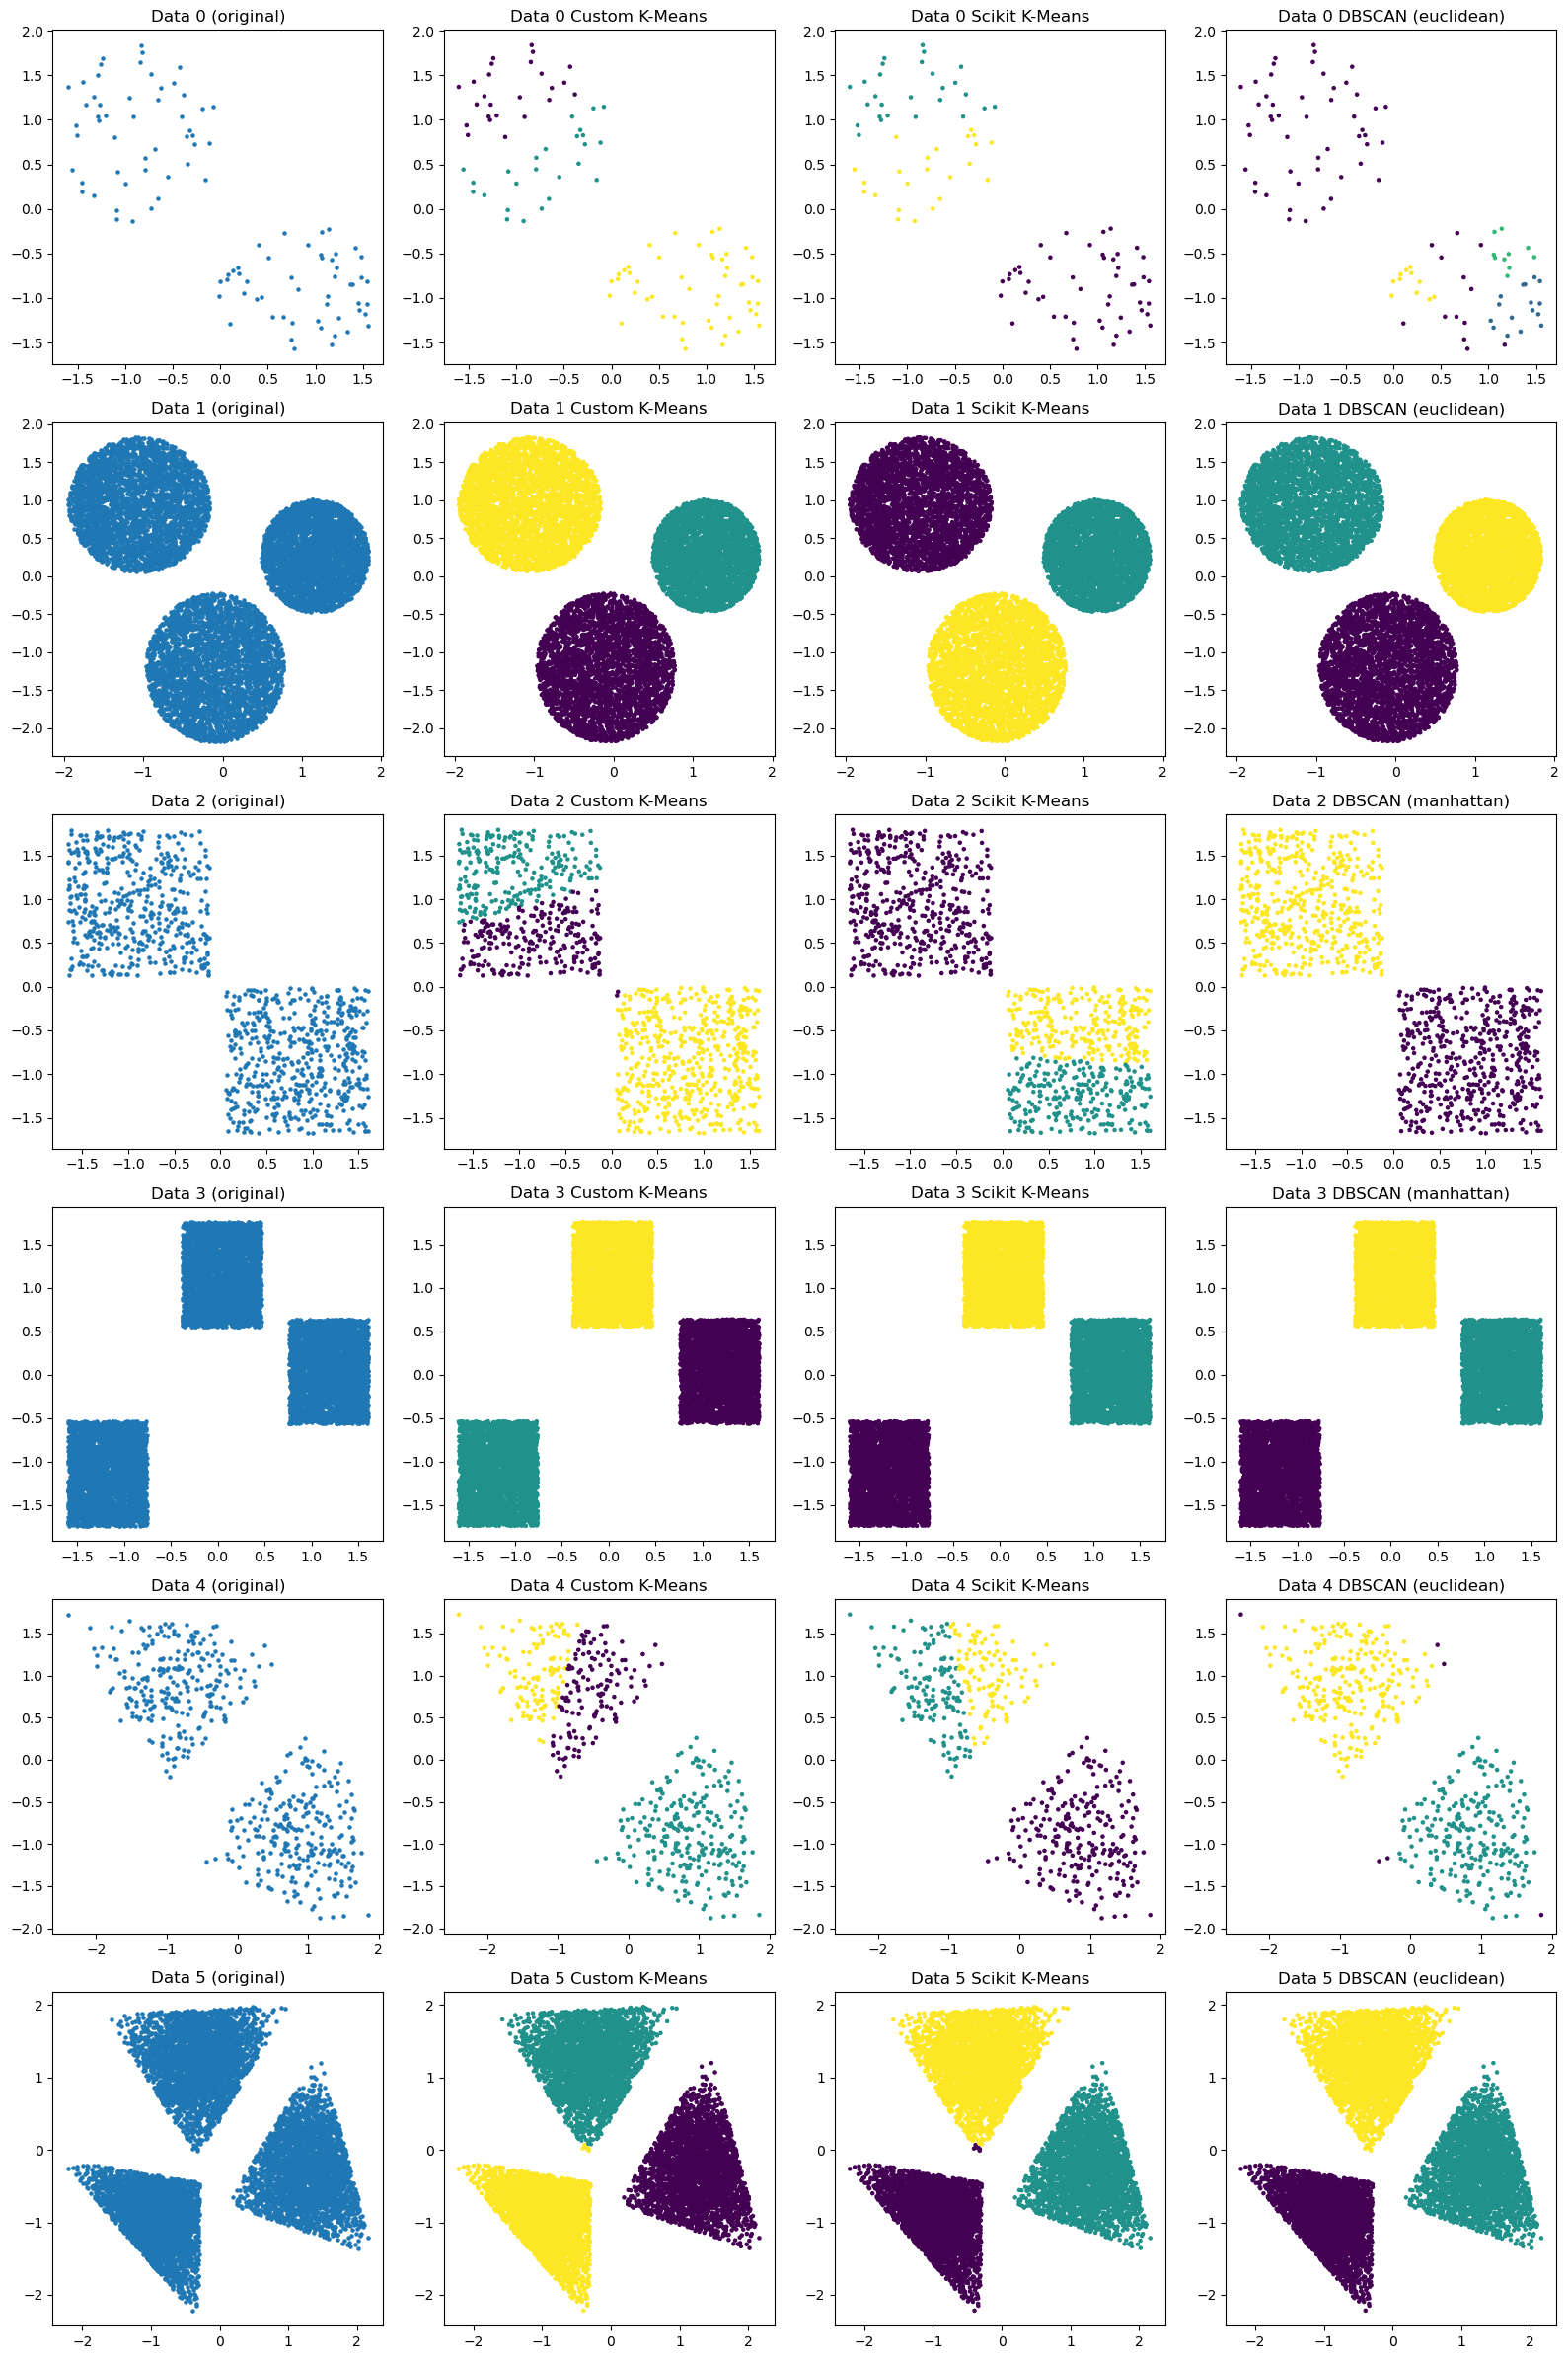

In [10]:
NUM_CLUSTERS = 3
FILE_LIST = [f"{i}.xlsx" for i in range(6)]

dataset_list = []

for file_name in FILE_LIST:
    dataframe = pd.read_excel(file_name)
    points = dataframe.iloc[:, :2].values
    dataset_list.append(points)

# ========================
# Custom clustering routine
# ========================
def custom_kmeans(data, k, max_iter=100):
    rng = np.random.default_rng(7)
    centroids = data[rng.choice(len(data), k, replace=False)]

    for _ in range(max_iter):
        dist = cdist(data, centroids)
        labels = np.argmin(dist, axis=1)

        new_centroids = np.array([
            data[labels == i].mean(axis=0) if np.any(labels == i) else centroids[i]
            for i in range(k)
        ])

        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return labels, centroids

def get_medoid(pts, metric="euclidean"):
    scipy_distance = "cityblock" if metric == "manhattan" else metric
    dist = cdist(pts, pts, metric=scipy_distance)
    return pts[np.argmin(dist.sum(axis=1))]

subplot_idx = 1
plt.figure(figsize=(16, 24))

for idx, points in enumerate(dataset_list):
    dist_metric = "manhattan" if idx in [2, 3] else "euclidean"

    scaled_points = StandardScaler().fit_transform(points)

    plt.subplot(len(dataset_list), 4, subplot_idx)
    plt.scatter(scaled_points[:, 0], scaled_points[:, 1], s=5)
    plt.title(f"Data {idx} (original)")
    subplot_idx += 1

    custom_labels, custom_centroids = custom_kmeans(scaled_points, NUM_CLUSTERS)

    plt.subplot(len(dataset_list), 4, subplot_idx)
    plt.scatter(scaled_points[:, 0], scaled_points[:, 1], c=custom_labels, s=5)
    plt.title(f"Data {idx} Custom K-Means")
    subplot_idx += 1

    kmeans_model = cluster.KMeans(n_clusters=NUM_CLUSTERS, n_init=10)
    sk_labels = kmeans_model.fit_predict(scaled_points)

    plt.subplot(len(dataset_list), 4, subplot_idx)
    plt.scatter(scaled_points[:, 0], scaled_points[:, 1], c=sk_labels, s=5)
    plt.title(f"Data {idx} Scikit K-Means")
    subplot_idx += 1
    
    dbscan_model = cluster.DBSCAN(eps=0.3, min_samples=10, metric=dist_metric)
    db_labels = dbscan_model.fit_predict(scaled_points)

    plt.subplot(len(dataset_list), 4, subplot_idx)
    plt.scatter(scaled_points[:, 0], scaled_points[:, 1], c=db_labels, s=5)
    plt.title(f"Data {idx} DBSCAN ({dist_metric})")
    subplot_idx += 1

    print(f"\nData {idx}")

    used_labels = sk_labels
    valid_labels = [l for l in np.unique(used_labels) if l != -1]

    centroid_list = []

    for group_id in valid_labels:
        group_points = scaled_points[used_labels == group_id]

        medoid_point = get_medoid(group_points, dist_metric)
        cluster_mean = group_points.mean(axis=0)

        centroid_list.append(cluster_mean)

        print(f"Group {group_id}")
        print("Medoid point:", medoid_point)

    if centroid_list:
        mean_centroid = np.mean(centroid_list, axis=0) * 1000
        print("Mean of centroids (scaled by 1000):", mean_centroid)

plt.tight_layout()
plt.show()